In [1]:
catalogo = [
    ("Toyota Hilux 2024", "camioneta pickup con motor turbodiesel, traccion 4x4, ideal para trabajo pesado y offroad"),
    ("Ford Ranger 2024", "pickup mediana con motor turbo y chasis reforzado, disenada para terrenos dificiles"),
    ("Nissan Leaf 2024", "hatchback 100% electrico, silencioso y eficiente, pensado para uso urbano diario"),
    ("Chevrolet Bolt EV 2024", "auto electrico compacto, carga rapida, bajo costo de mantenimiento, ideal para la ciudad"),
    ("BMW X5 2024", "suv premium con interior de cuero, tecnologia avanzada y motor de alto rendimiento"),
    ("Mercedes-Benz GLE 2024", "suv de lujo con suspension adaptativa y acabados premium"),
    ("Jeep Wrangler 2024", "todoterreno 4x4 con carroceria removible, disenado para exploracion extrema en montana y rios"),
    ("Land Rover Defender 2024", "todoterreno robusto con vadeo profundo, construido para climas humedos y terrenos extremos"),
]

pares = []
for i, (title_i, body_i) in enumerate(catalogo):
    pares.append((title_i, body_i, 1))
    for j, (title_j, body_j) in enumerate(catalogo):
        if i != j:
            pares.append((title_i, body_j, 0))

print(f"Total de pares: {len(pares)}  (8 positivos, {len(pares)-8} negativos)")

Total de pares: 64  (8 positivos, 56 negativos)


In [2]:
pares

[('Toyota Hilux 2024',
  'camioneta pickup con motor turbodiesel, traccion 4x4, ideal para trabajo pesado y offroad',
  1),
 ('Toyota Hilux 2024',
  'pickup mediana con motor turbo y chasis reforzado, disenada para terrenos dificiles',
  0),
 ('Toyota Hilux 2024',
  'hatchback 100% electrico, silencioso y eficiente, pensado para uso urbano diario',
  0),
 ('Toyota Hilux 2024',
  'auto electrico compacto, carga rapida, bajo costo de mantenimiento, ideal para la ciudad',
  0),
 ('Toyota Hilux 2024',
  'suv premium con interior de cuero, tecnologia avanzada y motor de alto rendimiento',
  0),
 ('Toyota Hilux 2024',
  'suv de lujo con suspension adaptativa y acabados premium',
  0),
 ('Toyota Hilux 2024',
  'todoterreno 4x4 con carroceria removible, disenado para exploracion extrema en montana y rios',
  0),
 ('Toyota Hilux 2024',
  'todoterreno robusto con vadeo profundo, construido para climas humedos y terrenos extremos',
  0),
 ('Ford Ranger 2024',
  'pickup mediana con motor turbo y c

In [3]:
import re
from collections import Counter

# ---- Parte 1: construir el vocabulario inicial (caracteres) a partir de "pares" ----
texto_completo = " ".join(texto_a + " " + texto_b for texto_a, texto_b, _ in pares).lower()
palabras = re.findall(r"[a-záéíóúñ]+", texto_completo)

def palabra_a_simbolos(palabra):
    return list(palabra) + ["</w>"]

vocab = Counter()
for p in palabras:
    vocab[tuple(palabra_a_simbolos(p))] += 1

# ---- Parte 2: contar pares de simbolos adyacentes ----
def contar_pares(vocab):
    conteo = Counter()
    for simbolos, freq in vocab.items():
        for i in range(len(simbolos) - 1):
            conteo[(simbolos[i], simbolos[i+1])] += freq
    return conteo

# ---- Parte 3: fusionar el par mas frecuente, repetir N veces ----
def fusionar(vocab, par):
    nuevo_vocab = Counter()
    a, b = par
    for simbolos, freq in vocab.items():
        nuevos_simbolos = []
        i = 0
        while i < len(simbolos):
            if i < len(simbolos)-1 and simbolos[i]==a and simbolos[i+1]==b:
                nuevos_simbolos.append(a+b)
                i += 2
            else:
                nuevos_simbolos.append(simbolos[i])
                i += 1
        nuevo_vocab[tuple(nuevos_simbolos)] += freq
    return nuevo_vocab

N_MERGES = 40
merges = []
for paso in range(N_MERGES):
    conteo_pares = contar_pares(vocab)
    if not conteo_pares:
        break
    mejor_par = conteo_pares.most_common(1)[0][0]
    vocab = fusionar(vocab, mejor_par)
    merges.append(mejor_par)

print(f"{len(merges)} fusiones aprendidas")

40 fusiones aprendidas


In [4]:
merges

[('o', '</w>'),
 ('a', '</w>'),
 ('e', 'n'),
 ('o', 'n'),
 ('e', 'r'),
 ('a', 'd'),
 ('s', '</w>'),
 ('on', '</w>'),
 ('a', 'r'),
 ('a', 'n'),
 ('d', 'e'),
 ('o', 'r'),
 ('d', 'i'),
 ('t', 'r'),
 ('y', '</w>'),
 ('l', 'e'),
 ('t', 'o</w>'),
 ('o', 't'),
 ('i', 'c'),
 ('c', 'on</w>'),
 ('p', 'ar'),
 ('par', 'a</w>'),
 ('r', 'o'),
 ('o', 's</w>'),
 ('m', 'i'),
 ('a', 'c'),
 ('r', 'en'),
 ('x', '</w>'),
 ('or', '</w>'),
 ('ad', 'o</w>'),
 ('r', 'e'),
 ('er', 'ren'),
 ('de', '</w>'),
 ('er', '</w>'),
 ('t', 'o'),
 ('p', '</w>'),
 ('m', 'ot'),
 ('mot', 'or</w>'),
 ('u', 'r'),
 ('ur', 'b')]

In [5]:
def encode(palabra, merges):
    simbolos = list(palabra.lower()) + ["</w>"]
    for a, b in merges:
        i = 0
        nuevos = []
        while i < len(simbolos):
            if i < len(simbolos)-1 and simbolos[i]==a and simbolos[i+1]==b:
                nuevos.append(a+b)
                i += 2
            else:
                nuevos.append(simbolos[i])
                i += 1
        simbolos = nuevos
    return simbolos

def construir_vocab(pares, merges):
    simbolos = set()
    for texto_a, texto_b, _ in pares:
        for palabra in (texto_a + " " + texto_b).lower().split():
            simbolos.update(encode(palabra, merges))
    simbolos.add("<unk>")
    vocab = sorted(simbolos)
    return {s: i for i, s in enumerate(vocab)}

token2id = construir_vocab(pares, merges)
print(f"Vocabulario final: {len(token2id)} simbolos")

Vocabulario final: 72 simbolos


In [6]:
token2id

{'%': 0,
 ',': 1,
 '-': 2,
 '0': 3,
 '1': 4,
 '2': 5,
 '4': 6,
 '5': 7,
 '</w>': 8,
 '<unk>': 9,
 'a': 10,
 'a</w>': 11,
 'ac': 12,
 'ad': 13,
 'ado</w>': 14,
 'an': 15,
 'ar': 16,
 'b': 17,
 'c': 18,
 'con</w>': 19,
 'd': 20,
 'de': 21,
 'de</w>': 22,
 'di': 23,
 'e': 24,
 'en': 25,
 'er': 26,
 'er</w>': 27,
 'erren': 28,
 'f': 29,
 'g': 30,
 'h': 31,
 'i': 32,
 'ic': 33,
 'j': 34,
 'k': 35,
 'l': 36,
 'le': 37,
 'm': 38,
 'mi': 39,
 'motor</w>': 40,
 'n': 41,
 'o': 42,
 'o</w>': 43,
 'on': 44,
 'on</w>': 45,
 'or': 46,
 'or</w>': 47,
 'os</w>': 48,
 'ot': 49,
 'p': 50,
 'p</w>': 51,
 'para</w>': 52,
 'r': 53,
 're': 54,
 'ren': 55,
 'ro': 56,
 's': 57,
 's</w>': 58,
 't': 59,
 'to': 60,
 'to</w>': 61,
 'tr': 62,
 'u': 63,
 'urb': 64,
 'v': 65,
 'w': 66,
 'x': 67,
 'x</w>': 68,
 'y': 69,
 'y</w>': 70,
 'z': 71}

In [7]:
import torch

def texto_a_ids(texto, merges, token2id):
    ids = []
    for palabra in texto.lower().split():
        for simbolo in encode(palabra, merges):
            ids.append(token2id.get(simbolo, token2id["<unk>"]))
    return torch.tensor(ids)

In [8]:
import torch.nn as nn

In [9]:
d = 16      # dimension del embedding
d_ff = 32   # dimension oculta del feed-forward

In [10]:
Wq = nn.Linear(d, d, bias=False)
Wk = nn.Linear(d, d, bias=False)
Wv = nn.Linear(d, d, bias=False)

print(Wq)
print(Wq.weight.shape)

Linear(in_features=16, out_features=16, bias=False)
torch.Size([16, 16])


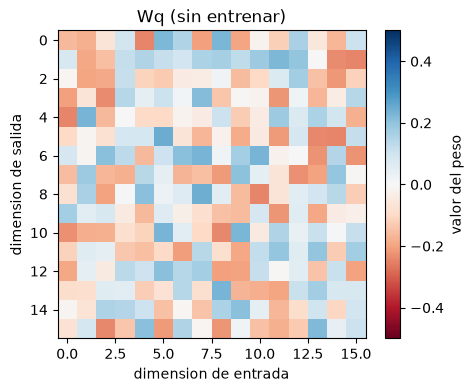

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(Wq.weight.detach().numpy(), cmap="RdBu", vmin=-0.5, vmax=0.5)
plt.colorbar(label="valor del peso")
plt.title("Wq (sin entrenar)")
plt.xlabel("dimension de entrada")
plt.ylabel("dimension de salida")
plt.show()

In [12]:
x = torch.randn(1, d)   # 1 "token" de ejemplo, con d=16 numeros (simula un embedding real)

x

tensor([[ 0.8871,  0.5332,  1.7909,  0.8687, -0.4475,  1.0918,  0.9330,  0.6519,
          0.5245,  0.3448, -0.3529,  0.4764, -0.9178, -1.5180, -1.0243, -0.2904]])

In [13]:
Q = Wq(x)
K = Wk(x)
V = Wv(x)

print("x:", x.shape)
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)

x: torch.Size([1, 16])
Q: torch.Size([1, 16])
K: torch.Size([1, 16])
V: torch.Size([1, 16])


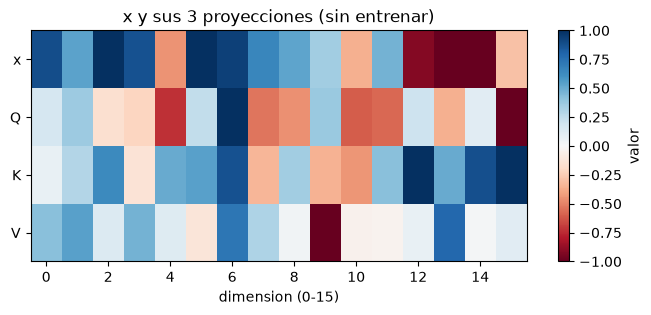

In [14]:
import numpy as np
np.set_printoptions(precision=2, suppress=True)

vectores = np.vstack([
    x.detach().numpy(),
    Q.detach().numpy(),
    K.detach().numpy(),
    V.detach().numpy(),
])

plt.figure(figsize=(8, 3))
plt.imshow(vectores, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="valor")
plt.yticks([0, 1, 2, 3], ["x", "Q", "K", "V"])
plt.xlabel("dimension (0-15)")
plt.title("x y sus 3 proyecciones (sin entrenar)")
plt.show()

Q = Qué busco

K = Qué ofrezco

V = Qué informo

In [15]:
print("x:", x.detach().numpy())
print("Q:", Q.detach().numpy())
print("K:", K.detach().numpy())
print("V:", V.detach().numpy())

x: [[ 0.89  0.53  1.79  0.87 -0.45  1.09  0.93  0.65  0.52  0.34 -0.35  0.48
  -0.92 -1.52 -1.02 -0.29]]
Q: [[ 0.16  0.37 -0.16 -0.21 -0.73  0.25  1.32 -0.54 -0.46  0.37 -0.61 -0.57
   0.21 -0.35  0.11 -1.19]]
K: [[ 0.07  0.29  0.64 -0.14  0.5   0.54  0.87 -0.34  0.35 -0.35 -0.44  0.42
   1.35  0.51  0.88  1.08]]
V: [[ 0.41  0.54  0.14  0.47  0.13 -0.12  0.72  0.31  0.04 -1.17 -0.04 -0.04
   0.07  0.79  0.02  0.11]]


In [16]:
scores = Q @ K.transpose(-2, -1) / (d ** 0.5)
print("scores:", scores.shape)
print(scores.detach().numpy())

scores: torch.Size([1, 1])
[[-0.05]]


In [18]:
x = torch.randn(5, d) 
x

tensor([[ 0.2574, -0.3507,  0.6060, -1.6281, -0.2209,  0.7981, -2.5006, -1.8532,
         -0.4258,  2.5189, -0.2830,  0.8656, -2.0717,  0.3619,  0.5544, -0.5980],
        [-1.2674, -0.0779, -0.5416, -0.0689,  0.7233,  0.8701,  0.8791, -0.3925,
         -1.4186, -0.5773, -1.3580,  1.5472, -0.1657, -0.0761,  0.0221, -0.7505],
        [ 0.6325,  2.6834,  2.1915, -0.4439, -1.9059, -1.1342, -0.4961, -0.7598,
         -0.0739,  0.4994,  1.1072, -0.5387,  0.0631,  1.1751,  0.3252,  0.9299],
        [ 0.4888, -0.3254,  0.8488, -0.8788, -0.2805,  1.8086, -1.3007,  0.6855,
          1.4978, -1.2111, -0.0122,  0.0524, -0.4033, -0.4715,  0.4815,  0.8771],
        [ 0.2096, -0.1676,  0.2984, -0.3708,  1.4209, -1.2433, -2.0696,  0.3441,
          0.0207,  1.4401,  0.9075, -0.0696,  1.3175,  0.2759, -0.3704, -0.2717]])

In [19]:
Q = Wq(x)
K = Wk(x)
V = Wv(x)

print("x:", x.shape)
print("Q:", Q.shape)

x: torch.Size([5, 16])
Q: torch.Size([5, 16])


In [20]:
scores = Q @ K.transpose(-2, -1) / (d ** 0.5)
print("scores:", scores.shape)

scores: torch.Size([5, 5])


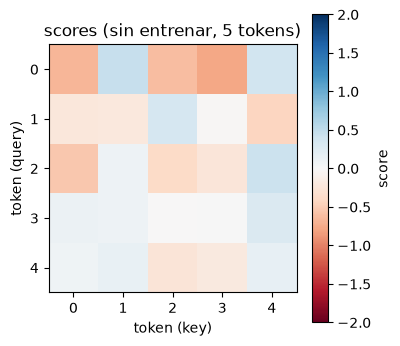

In [21]:
plt.figure(figsize=(4, 4))
plt.imshow(scores.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2)
plt.colorbar(label="score")
plt.xlabel("token (key)")
plt.ylabel("token (query)")
plt.xticks(range(5))
plt.yticks(range(5))
plt.title("scores (sin entrenar, 5 tokens)")
plt.show()

In [22]:
weights = torch.softmax(scores, dim=-1)
print("weights:", weights.shape)
print(weights.detach().numpy())
print("\nsuma por fila:", weights.sum(dim=-1).detach().numpy())

weights: torch.Size([5, 5])
[[0.11 0.35 0.12 0.1  0.32]
 [0.17 0.17 0.3  0.21 0.14]
 [0.12 0.24 0.14 0.17 0.33]
 [0.2  0.2  0.18 0.18 0.24]
 [0.21 0.23 0.15 0.16 0.23]]

suma por fila: [1. 1. 1. 1. 1.]


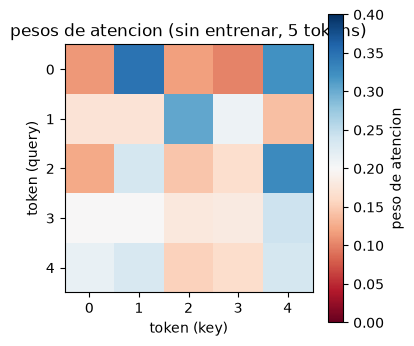

In [23]:
plt.figure(figsize=(4, 4))
plt.imshow(weights.detach().numpy(), cmap="RdBu", vmin=0, vmax=0.4)
plt.colorbar(label="peso de atencion")
plt.xlabel("token (key)")
plt.ylabel("token (query)")
plt.xticks(range(5))
plt.yticks(range(5))
plt.title("pesos de atencion (sin entrenar, 5 tokens)")
plt.show()

In [24]:
output = weights @ V
print("output:", output.shape)
print(output.detach().numpy())

output: torch.Size([5, 16])
[[ 0.1   0.05  0.26  0.21  0.07  0.05 -0.58  0.05 -0.15 -0.03  0.    0.41
  -0.05  0.16 -0.16 -0.07]
 [ 0.27  0.48  0.51 -0.35 -0.03  0.32 -0.16  0.04  0.01 -0.26 -0.07  0.74
   0.17  0.1  -0.19 -0.26]
 [ 0.24  0.2   0.33  0.07  0.09  0.08 -0.45  0.03 -0.06 -0.11  0.05  0.56
   0.02  0.19 -0.13 -0.07]
 [ 0.23  0.34  0.43 -0.07  0.05  0.2  -0.38  0.02 -0.12 -0.26 -0.02  0.67
   0.1   0.17 -0.16 -0.19]
 [ 0.18  0.3   0.41  0.    0.06  0.19 -0.43  0.03 -0.19 -0.26 -0.03  0.63
   0.09  0.17 -0.17 -0.21]]


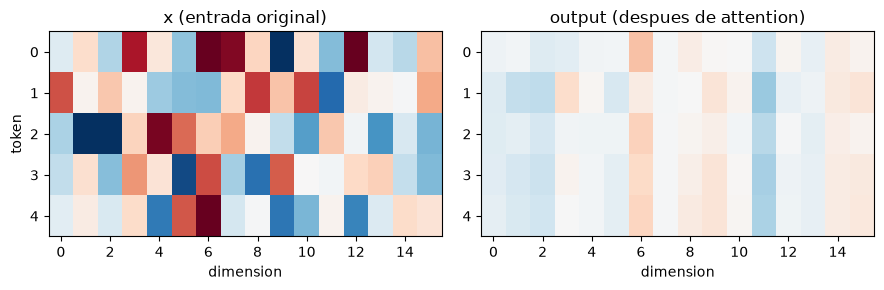

In [25]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 2, 1)
plt.imshow(x.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
plt.title("x (entrada original)")
plt.xlabel("dimension")
plt.ylabel("token")

plt.subplot(1, 2, 2)
plt.imshow(output.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
plt.title("output (despues de attention)")
plt.xlabel("dimension")

plt.tight_layout()
plt.show()

In [26]:
vocab_size = len(token2id)
max_len = 30

token_embed = nn.Embedding(vocab_size, d)
pos_embed = nn.Embedding(max_len, d)

print("vocab_size:", vocab_size)

vocab_size: 72


In [27]:
texto = "camioneta pickup con motor turbodiesel"
ids = texto_a_ids(texto, merges, token2id)
print("ids:", ids)
print("cantidad de tokens:", ids.shape[0])

ids: tensor([18, 10, 39, 44, 24, 59, 11, 50, 33, 35, 63, 51, 19, 40, 59, 64, 42, 23,
        24, 57, 24, 36,  8])
cantidad de tokens: 23


In [28]:
positions = torch.arange(len(ids))
x = token_embed(ids) + pos_embed(positions)
print("x:", x.shape)

x: torch.Size([23, 16])


In [29]:
Q = Wq(x)
K = Wk(x)
V = Wv(x)
scores = Q @ K.transpose(-2, -1) / (d ** 0.5)
weights = torch.softmax(scores, dim=-1)
output = weights @ V

print("weights:", weights.shape)
print("output:", output.shape)

weights: torch.Size([23, 23])
output: torch.Size([23, 16])


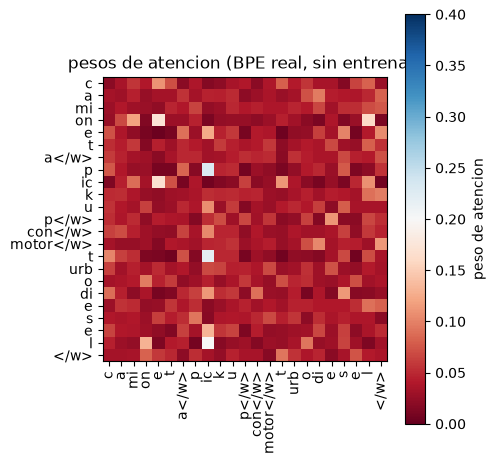

In [30]:
tokens = encode(texto.split()[0], merges)  # etiquetas para el primer token de la oracion, ajustar si quieres mas
etiquetas = []
for palabra in texto.lower().split():
    etiquetas += encode(palabra, merges)

plt.figure(figsize=(5, 5))
plt.imshow(weights.detach().numpy(), cmap="RdBu", vmin=0, vmax=0.4)
plt.colorbar(label="peso de atencion")
plt.xticks(range(len(etiquetas)), etiquetas, rotation=90)
plt.yticks(range(len(etiquetas)), etiquetas)
plt.title("pesos de atencion (BPE real, sin entrenar)")
plt.tight_layout()
plt.show()

In [31]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Recolectar todo el texto del corpus (igual que hicimos a mano)
textos_entrenamiento = [texto_a + " " + texto_b for texto_a, texto_b, _ in pares]

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()   # primero separa por espacios, BPE trabaja dentro de cada palabra

trainer = BpeTrainer(
    special_tokens=["[UNK]"],
    vocab_size=500,       # tamaño maximo del vocabulario final
    min_frequency=2,      # un par debe aparecer al menos 2 veces para fusionarse
)

tokenizer.train_from_iterator(textos_entrenamiento, trainer)

In [33]:
for palabra in ["camioneta", "motor", "electrico", "wayra piquero", "wayra sacha"]:
    output = tokenizer.encode(palabra)
    print(f"{palabra:14} -> {output.tokens}")

camioneta      -> ['camioneta']
motor          -> ['motor']
electrico      -> ['electrico']
wayra piquero  -> ['[UNK]', 'a', 'y', 'ra', 'p', 'i', '[UNK]', 'u', 'ero']
wayra sacha    -> ['[UNK]', 'a', 'y', 'ra', 's', 'a', 'ch', 'a']
